In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
url = "https://raw.githubusercontent.com/SivadithiyanOfcl/SDSS17/main/star_classification.csv"
df = pd.read_csv(url)

In [11]:
df.shape

(100000, 18)

In [12]:
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [13]:
# ============================================================
# BASIC EDA
# ============================================================

In [14]:
# Check data types, non-null counts, and overall structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [15]:
# Check for missing values
print(df.isnull().sum())

# Check for duplicate rows
print("Duplicates:", df.duplicated().sum())

# Class distribution (target variable)
print(df['class'].value_counts())
print(df['class'].value_counts(normalize=True))

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64
Duplicates: 0
class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64
class
GALAXY    0.59445
STAR      0.21594
QSO       0.18961
Name: proportion, dtype: float64


In [16]:
# ============================================================
# IDENTIFIER / METADATA COLUMN CHECK
# ============================================================

In [17]:
# Candidate identifier/metadata columns that may not carry predictive signal
id_like_cols = ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID',
                 'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']

for col in id_like_cols:
    print(col, "-> unique values:", df[col].nunique())

obj_ID -> unique values: 78053
run_ID -> unique values: 430
rerun_ID -> unique values: 1
cam_col -> unique values: 6
field_ID -> unique values: 856
spec_obj_ID -> unique values: 100000
plate -> unique values: 6284
MJD -> unique values: 2180
fiber_ID -> unique values: 1000


In [18]:
# ============================================================
# DROP PURE IDENTIFIER COLUMNS
# ============================================================

In [19]:
# rerun_ID: zero variance (single unique value across all rows)
# obj_ID: catalog identifier, not a physical property, near-unique
# spec_obj_ID: fully unique per row (100,000/100,000) -> pure row identifier, leakage risk
df = df.drop(columns=['rerun_ID', 'obj_ID', 'spec_obj_ID'])

df.shape

(100000, 15)

In [21]:
# ============================================================
# OUTLIER & SENTINEL VALUE CHECK
# ============================================================

In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
alpha,100000.0,177.629117,96.502241,0.005528,127.518222,180.900700,233.895005,359.999810
delta,100000.0,24.135305,19.644665,-18.785328,5.146771,23.645922,39.901550,83.000519
u,100000.0,21.980468,31.769291,-9999.000000,20.352353,22.179135,23.687440,32.781390
g,100000.0,20.531387,31.750292,-9999.000000,18.965230,21.099835,22.123767,31.602240
r,100000.0,19.645762,1.854760,9.822070,18.135828,20.125290,21.044785,29.571860
i,100000.0,19.084854,1.757895,9.469903,17.732285,19.405145,20.396495,32.141470
z,100000.0,18.668810,31.728152,-9999.000000,17.460677,19.004595,19.921120,29.383740
run_ID,100000.0,4481.366060,1964.764593,109.000000,3187.000000,4188.000000,5326.000000,8162.000000
cam_col,100000.0,3.511610,1.586912,1.000000,2.000000,4.000000,5.000000,6.000000
field_ID,100000.0,186.130520,149.011073,11.000000,82.000000,146.000000,241.000000,989.000000


In [22]:
# ============================================================
# SENTINEL VALUE (-9999) INVESTIGATION
# ============================================================

In [23]:
sentinel_cols = ['u', 'g', 'z']

for col in sentinel_cols:
    count = (df[col] == -9999).sum()
    print(f"{col}: {count} rows with -9999 ({count/len(df)*100:.3f}%)")

# Check if -9999 rows overlap (same rows affected across u, g, z) or are independent
mask = (df[sentinel_cols] == -9999).any(axis=1)
print("\nTotal rows affected:", mask.sum())
df[mask][sentinel_cols]

u: 1 rows with -9999 (0.001%)
g: 1 rows with -9999 (0.001%)
z: 1 rows with -9999 (0.001%)

Total rows affected: 1


,u,g,z
79543,-9999.0,-9999.0,-9999.0


In [24]:
# ============================================================
# DROP SENTINEL VALUE ROW
# ============================================================

In [25]:
# Single row with -9999 placeholder across u, g, z (failed measurement)
# Negligible impact (1/100000), dropping instead of imputing
df = df[df['u'] != -9999].reset_index(drop=True)

df.shape

(99999, 15)

In [27]:
# ============================================================
# IQR OUTLIER CHECK
# ============================================================

In [28]:
numeric_cols = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {outliers} outliers ({outliers/len(df)*100:.2f}%), bounds=({lower:.2f}, {upper:.2f})")

alpha: 0 outliers (0.00%), bounds=(-32.05, 393.46)
delta: 0 outliers (0.00%), bounds=(-46.98, 92.03)
u: 55 outliers (0.06%), bounds=(15.35, 28.69)
g: 98 outliers (0.10%), bounds=(14.23, 26.86)
r: 132 outliers (0.13%), bounds=(13.77, 25.41)
i: 198 outliers (0.20%), bounds=(13.74, 24.39)
z: 319 outliers (0.32%), bounds=(13.77, 23.61)
redshift: 8989 outliers (8.99%), bounds=(-0.92, 1.68)


In [29]:
# ============================================================
# REDSHIFT BY CLASS CHECK
# ============================================================

In [30]:
df.groupby('class')['redshift'].describe()

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
GALAXY,59445.0,0.421596,0.264858,-0.009971,0.164527,0.456274,0.594699,1.995524
QSO,18961.0,1.719676,0.913954,0.000461,1.106605,1.617232,2.220279,7.011245
STAR,21593.0,-0.000115,0.000465,-0.004136,-0.000295,-0.000076,0.000075,0.004153


In [31]:
# ============================================================
# CORRELATION MATRIX
# ============================================================

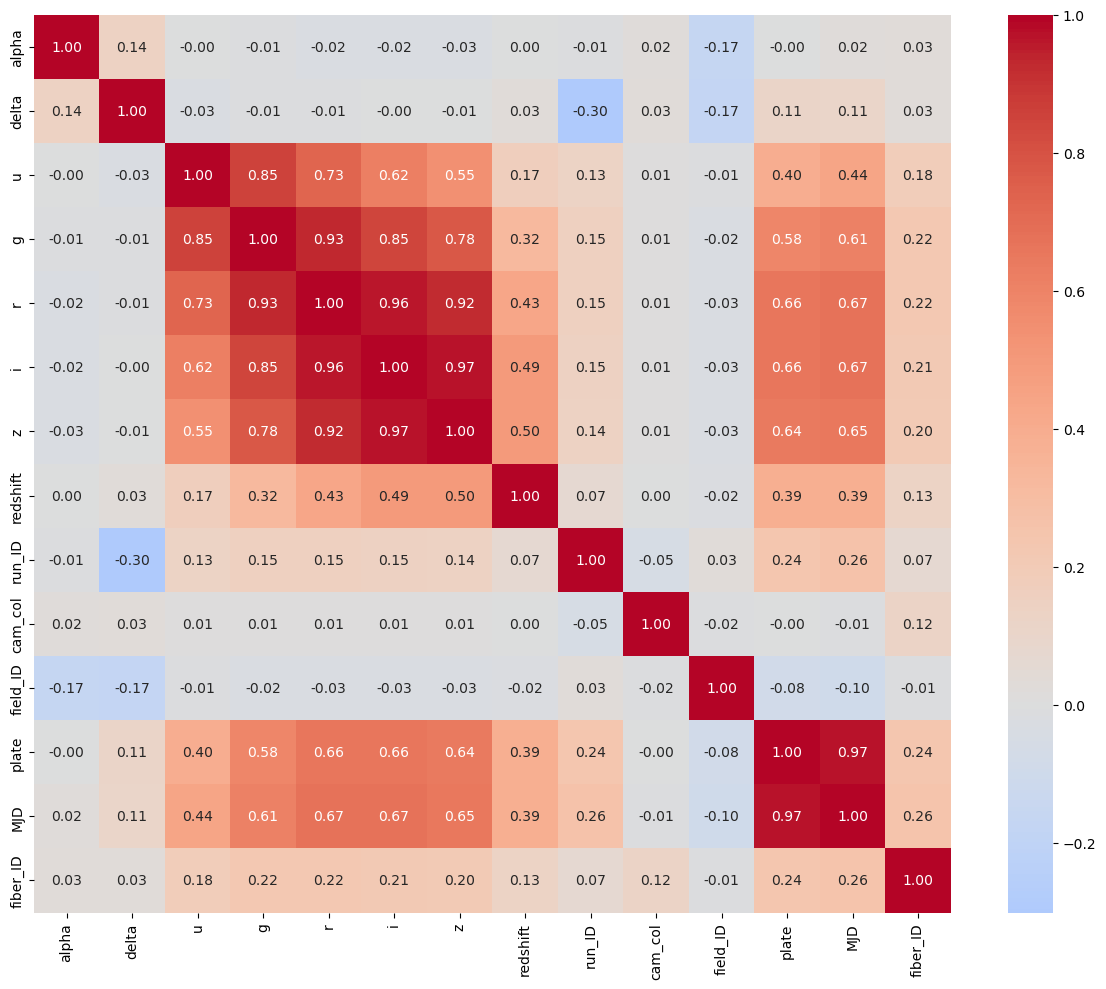

In [32]:
corr_cols = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift',
             'run_ID', 'cam_col', 'field_ID', 'plate', 'MJD', 'fiber_ID']

plt.figure(figsize=(12, 10))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# VIF CHECK
# ============================================================

In [34]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [35]:
vif_cols = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift',
            'run_ID', 'cam_col', 'field_ID', 'plate', 'MJD', 'fiber_ID']

X_vif = df[vif_cols]

vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data.sort_values('VIF', ascending=False))

     feature          VIF
5          i  5011.903705
4          r  4782.696328
6          z  2403.036002
3          g  1914.807117
2          u   426.973947
12       MJD   271.058141
8     run_ID     7.553805
11     plate     6.599056
9    cam_col     6.003023
0      alpha     4.600993
13  fiber_ID     4.064184
1      delta     3.037219
10  field_ID     2.706928
7   redshift     2.276423


In [36]:
# ============================================================
# TARGET ENCODING
# ============================================================

In [38]:
from sklearn.preprocessing import LabelEncoder

In [39]:
le = LabelEncoder()
df['class_encoded'] = le.fit_transform(df['class'])

# Check mapping
print(dict(zip(le.classes_, le.transform(le.classes_))))
df[['class', 'class_encoded']].head()

{'GALAXY': np.int64(0), 'QSO': np.int64(1), 'STAR': np.int64(2)}


,class,class_encoded
0,GALAXY,0
1,GALAXY,0
2,GALAXY,0
3,GALAXY,0
4,GALAXY,0


In [40]:
df.head()

,alpha,delta,u,g,r,i,z,run_ID,cam_col,field_ID,class,redshift,plate,MJD,fiber_ID,class_encoded
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,2,79,GALAXY,0.634794,5812,56354,171,0
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,5,119,GALAXY,0.779136,10445,58158,427,0
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,2,120,GALAXY,0.644195,4576,55592,299,0
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,3,214,GALAXY,0.932346,9149,58039,775,0
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,3,137,GALAXY,0.116123,6121,56187,842,0


In [42]:
df["class_encoded"].value_counts()

class_encoded
0    59445
2    21593
1    18961
Name: count, dtype: int64

In [43]:
# ============================================================
# TRAIN/TEST SPLIT
# ============================================================

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
# Drop original string class column and non-feature ID columns, keep encoded target
X = df.drop(columns=['class', 'class_encoded'])
y = df['class_encoded']

# Stratified split to preserve class proportions (GALAXY/QSO/STAR imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(79999, 14) (20000, 14)
class_encoded
0    0.594457
2    0.215928
1    0.189615
Name: proportion, dtype: float64
class_encoded
0    0.59445
2    0.21595
1    0.18960
Name: proportion, dtype: float64


In [46]:
# ============================================================
# SMOTE (TRAIN SET ONLY)
# ============================================================

In [47]:
from imblearn.over_sampling import SMOTE

In [48]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(y_train_sm.value_counts())

class_encoded
0    47556
2    47556
1    47556
Name: count, dtype: int64


In [49]:
# ============================================================
# BASELINE XGBOOST MODEL
# ============================================================

In [50]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score

In [51]:
xgb_baseline = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42
)

xgb_baseline.fit(X_train_sm, y_train_sm)

# Predict on real (imbalanced) test set
y_pred = xgb_baseline.predict(X_test)
y_proba = xgb_baseline.predict_proba(X_test)

print(classification_report(y_test, y_pred, target_names=['GALAXY', 'QSO', 'STAR']))
print("ROC-AUC (macro, OvR):", roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro'))
print("F1 macro:", f1_score(y_test, y_pred, average='macro'))

              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98     11889
         QSO       0.95      0.95      0.95      3792
        STAR       0.99      1.00      0.99      4319

    accuracy                           0.98     20000
   macro avg       0.97      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000

ROC-AUC (macro, OvR): 0.9955576147102718
F1 macro: 0.9743307162979123


In [52]:
# ============================================================
# OVERFIT CHECK
# ============================================================

In [53]:
from sklearn.metrics import f1_score

In [55]:
# Train performance (on SMOTE-balanced train set)
y_train_pred = xgb_baseline.predict(X_train_sm)
train_f1 = f1_score(y_train_sm, y_train_pred, average='macro')

# Test performance (on real imbalanced test set) — already computed above
test_f1 = f1_score(y_test, y_pred, average='macro')

print("Train F1 macro:", train_f1)
print("Test F1 macro:", test_f1)
print("Gap:", train_f1 - test_f1)

Train F1 macro: 0.9918827055288867
Test F1 macro: 0.9743307162979123
Gap: 0.01755198923097434


In [56]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

In [57]:
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_baseline.feature_importances_
}).sort_values('importance', ascending=False)

print(importance)

     feature  importance
10  redshift    0.826547
3          g    0.064998
2          u    0.027998
6          z    0.020028
5          i    0.011037
11     plate    0.010220
4          r    0.006738
12       MJD    0.006468
1      delta    0.004603
7     run_ID    0.004434
13  fiber_ID    0.004401
8    cam_col    0.004361
9   field_ID    0.004159
0      alpha    0.004007


In [59]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

In [60]:
from sklearn.metrics import confusion_matrix

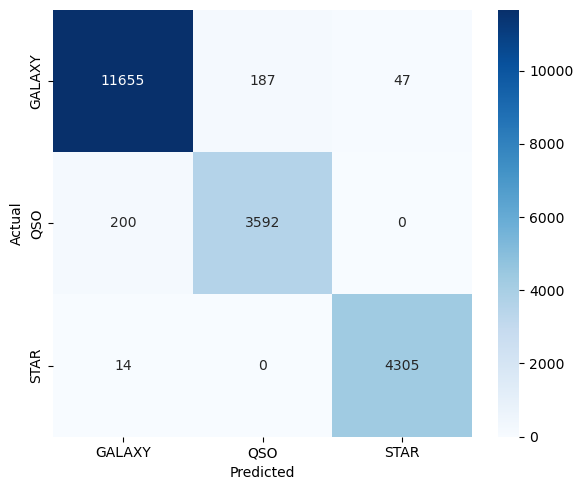

In [61]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['GALAXY', 'QSO', 'STAR'],
            yticklabels=['GALAXY', 'QSO', 'STAR'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [62]:
# ============================================================
# MULTICLASS ROC-AUC (One-vs-Rest)
# ============================================================

In [63]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

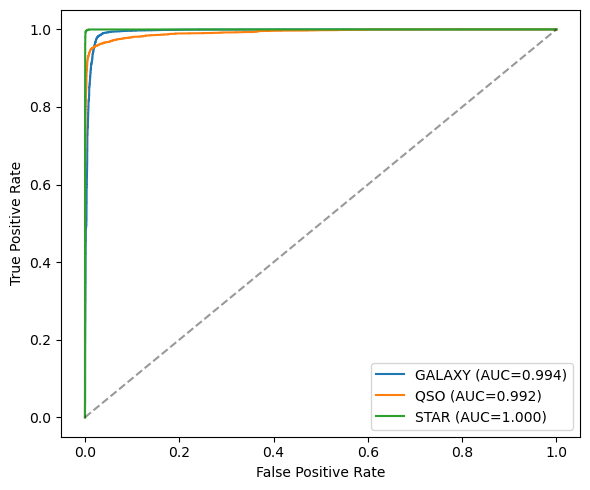

In [64]:
# Binarize test labels, aligned to model.classes_ order 
classes = xgb_baseline.classes_
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(6, 5))
for i, cls_name in zip(classes, ['GALAXY', 'QSO', 'STAR']):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{cls_name} (AUC={roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

In [65]:
# ============================================================
# COHEN'S KAPPA & LOG LOSS
# ============================================================

In [66]:
from sklearn.metrics import cohen_kappa_score, log_loss

In [67]:
kappa = cohen_kappa_score(y_test, y_pred)
logloss = log_loss(y_test, y_proba)

print("Cohen's Kappa:", kappa)
print("Log Loss:", logloss)

Cohen's Kappa: 0.9603123986507225
Log Loss: 0.07815064562338057


In [68]:
# ============================================================
# CROSS-VALIDATION 
# ============================================================

In [69]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [70]:
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(objective='multi:softprob', num_class=3,
                           eval_metric='mlogloss', random_state=42))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Full X, y (not the pre-split SMOTE'd version) — pipeline handles SMOTE internally per fold
cv_scores = cross_val_score(pipeline, X, y, cv=skf, scoring='f1_macro')

print("CV F1 macro scores:", cv_scores)
print("CV Mean:", cv_scores.mean(), "± ", cv_scores.std())

CV F1 macro scores: [0.97148856 0.97203348 0.97451016 0.97233532 0.97287302]
CV Mean: 0.972648107395963 ±  0.0010332460667246538
